# Cease & Desist Classification Agent
### LangGraph Multi-Agent Pipeline

This notebook walks through a multi-agent system that:
1. Scans a folder of PDFs and allocates a unique Document ID per file
2. Converts each PDF to Markdown (native or scanned/OCR)
3. Classifies the document as **CEASE**, **UNCERTAIN**, or **IRRELEVANT**
4. Writes results to SQLite and a flat JSONL archive
5. Logs all actions in an audit trail
6. Pauses for **Human-in-the-Loop (HITL)** review when classification is UNCERTAIN
7. Moves processed files to a `Completed/` subfolder



## Install Dependencies

In [1]:
%pip install langgraph langchain-groq langchain-core python-dotenv pydantic pdfplumber pypdf pytesseract Pillow pymupdf --quiet

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## Imports

In [2]:
from datetime import datetime
import json
import os
import re
import shutil
import sqlite3
from dotenv import load_dotenv
from typing import Annotated, Literal
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.types import interrupt, Command
from langgraph.graph.message import add_messages
from langchain_groq import ChatGroq
from langchain_core.messages import SystemMessage
import operator
from pydantic import BaseModel, Field, field_validator
from langgraph.checkpoint.memory import MemorySaver

print("✅ Imports successful")

✅ Imports successful


## Environment Setup

Loads credentials and config from a `.env` file in the same directory.

Expected `.env` keys:
```
GROQ_API_KEY       = your_groq_api_key
MODEL_NAME         = llama-3.3-70b-versatile
MODEL_TEMPERATURE  = 0
SQL_LITE_DB_PATH   = cease_desist.db
AUDIT_LOG_PATH     = cease_desist_audit.log
ARCHIVE_PATH       = cease_desist_archive.jsonl
```

In [3]:
load_dotenv(".env")

print(f"Model      : {os.getenv('MODEL_NAME')}")
print(f"Temperature: {os.getenv('MODEL_TEMPERATURE')}")
print(f"DB Path    : {os.getenv('SQL_LITE_DB_PATH')}")
print(f"Audit Log  : {os.getenv('AUDIT_LOG_PATH')}")
print(f"Archive    : {os.getenv('ARCHIVE_PATH')}")

Model      : llama-3.3-70b-versatile
Temperature: 0
DB Path    : DB\\classification_agent.db
Audit Log  : audits\\audit_log.log
Archive    : archives\\classification_agent_archive.jsonl


## Classification Prompt

The prompt instructs the LLM to classify the document into one of 3 categories with a structured JSON response.

In [4]:
CLASSIFY_PROMPT = """
You are a legal document classification expert specializing in customer communication compliance for the Bank (Wells Fargo).

## TASK
Analyze the provided document and classify it into exactly ONE of the following three categories:

### CATEGORIES

1. CEASE  — Valid Cease & Desist Request
   - Customer explicitly or clearly requests to STOP all direct communication
   - Phrases like: "stop contacting me", "do not call", "no further communication",
     "cease all contact", "I do not wish to be contacted", "remove me from your list"
   - May reference legal rights (TCPA, FDCPA, DNC registry, GDPR, etc.)
   - Intent to stop communication is CLEAR and UNAMBIGUOUS

2. UNCERTAIN — Requires Manual Review
   - Some signals of a cease & desist but unclear or incomplete
   - Ambiguous, indirect, or emotionally driven without clear stop-contact intent
   - Mixed signals, partial opt-out, or contradictory statements
   - Not confident enough to classify as CEASE or IRRELEVANT

3. IRRELEVANT — Not a Cease & Desist Request
   - NO indication of a desire to stop communication
   - General complaints, inquiries, billing disputes, service requests, feedback

## DOCUMENT TO ANALYZE
{document_text}

## OUTPUT FORMAT
Respond ONLY in the following JSON format with no additional text or markdown:

{{
  "classification": "<CEASE | UNCERTAIN | IRRELEVANT>",
  "confidence_score": <integer 1-100>,
  "reasoning": "<2-3 sentences>",
  "key_phrases": ["<phrase1>", "<phrase2>", "<phrase3>"],
  "urgency_level": "<HIGH | MEDIUM | LOW>",
  "recommended_action": "<one line next step>"
}}

## SCORING GUIDANCE
85-100 → CEASE       : Explicit unambiguous request, possibly with legal citations
70-84  → CEASE       : Clear intent, informal but direct
40-69  → UNCERTAIN   : Ambiguous, mixed signals
20-39  → UNCERTAIN   : Weak signals, human review required
1-19   → IRRELEVANT  : No cease & desist indicators

## CRITICAL RULES
- When in doubt, prefer UNCERTAIN over IRRELEVANT (safer to escalate than to miss)
- NEVER classify as CEASE unless intent is explicit or strongly implied
- key_phrases must be direct quotes from the document, not paraphrased
"""

print("✅ Prompt defined")

✅ Prompt defined


##LLM Initialization

In [5]:
llm = ChatGroq(
    model=os.getenv('MODEL_NAME'),
    temperature=float(os.getenv('MODEL_TEMPERATURE', 0))
)

print(f"✅ LLM initialized: {os.getenv('MODEL_NAME')}")

✅ LLM initialized: llama-3.3-70b-versatile


## State & Pydantic Schema

- `ClassificationState` — shared state passed across all LangGraph nodes
- `ClassificationResult` — structured output schema returned by the LLM

### v2 upgrade — `ClassificationResult`
| Field | v1 | v2 |
|---|---|---|
| `confidence_score` | `int` | `int = Field(ge=1, le=100)` |
| `urgency_level` | `str` | `Literal["HIGH", "MEDIUM", "LOW"]` |
| `coerce_to_int` | ❌ | ✅ `@field_validator` — converts `"100"` → `100` |

> The validator fixes a Groq model quirk where `confidence_score` is occasionally returned as a string (e.g. `"100"`) instead of an integer, which causes a `400 BadRequestError`.

In [6]:
class ClassificationState(TypedDict):
    pdf_file_path:               str
    markdown_dict:               dict
    agent_classification_result: dict
    hitl_decision:               str
    document_id:                 str
    messages:                    Annotated[list, add_messages]
    audit_logs:                  Annotated[list[str], operator.add]
    classification:              str
    error:                       Annotated[list[str], operator.add]


class ClassificationResult(BaseModel):
    classification:     Literal["CEASE", "UNCERTAIN", "IRRELEVANT"]
    confidence_score:   int = Field(ge=1, le=100)
    reasoning:          str
    key_phrases:        list[str]
    urgency_level:      Literal["HIGH", "MEDIUM", "LOW"]
    recommended_action: str

    @field_validator("confidence_score", mode="before")
    @classmethod
    def coerce_to_int(cls, v):
        return int(v)  # converts "100" → 100 silently


print("✅ State and schema defined")

✅ State and schema defined


## Helper Utilities

In [7]:
def _now() -> str:
    return datetime.now().strftime("%Y-%m-%d %H:%M:%S")


def _audit_entry(agent: str, message: str, color: str = "black") -> str:
    """Returns a colorized, timestamped audit log entry."""
    dict_colors = {
        "blue":   "\033[94m",
        "green":  "\033[92m",
        "yellow": "\033[93m",
        "red":    "\033[91m",
        "endc":   "\033[0m"
    }
    return (
        f"[{_now()}] "
        f"{dict_colors.get('green', '')}[{agent}]{dict_colors.get('endc', '')}"
        f"{dict_colors.get(color, '')} {message}{dict_colors.get('endc', '')}"
    )


def _init_db():
    """Creates the SQLite classifications table if it doesn't exist."""
    conn = sqlite3.connect(os.getenv("SQL_LITE_DB_PATH"))
    conn.execute("""
        CREATE TABLE IF NOT EXISTS classifications (
            document_id        TEXT PRIMARY KEY,
            document_text      TEXT,
            classification     TEXT,
            confidence_score   INTEGER,
            reasoning          TEXT,
            key_phrases        TEXT,
            pdf_file_path      TEXT,
            recommended_action TEXT,
            hitl_decision      TEXT,
            created_at         TEXT
        )
    """)
    conn.commit()
    conn.close()


def pdf_to_markdown_tool(pdf_path: str) -> dict:
    """Converts a PDF (native or scanned) to Markdown using pdf_to_markdown module."""
    from pdf_to_markdown import pdf_to_markdown
    return pdf_to_markdown(pdf_path)


def get_next_doc_index(audit_log_path: str) -> int:
    """
    Reads the audit log and returns the next available document index.
    Ensures document IDs never repeat across multiple runs.
    
    Example: if audit log contains DOC-20260322143000-003,
             the next run starts from index 4.
    """
    if not os.path.exists(audit_log_path):
        return 1

    with open(audit_log_path, "r", encoding="utf-8") as f:
        content = f.read()

    matches = re.findall(r"DOC-\d{14}-(\d{3})", content)

    if not matches:
        return 1

    return max(int(m) for m in matches) + 1


print("✅ Helper utilities defined")

✅ Helper utilities defined


## Agent Definitions

Each function is a **LangGraph node** — receives the shared state and returns a partial state update.

| Agent | Responsibility |
|---|---|
| `manager_agent` | Converts PDF → Markdown, logs metadata |
| `classification_agent` | Calls LLM with structured output, handles errors gracefully |
| `hitl_agent` | Pauses graph for human decision (UNCERTAIN only) |
| `database_agent` | Writes classification result to SQLite |
| `archiving_agent` | Appends result to JSONL flat file |
| `audit_agent` | Writes full timestamped audit trail to log file |

In [8]:
def manager_agent(state: ClassificationState) -> ClassificationState:
    logs = []
    logs.append(_audit_entry("MANAGER", f"Received document_id={state['document_id']}. Starting pipeline."))
    print(f"[Manager] Processing document: {state['document_id']}")
    markdown_dict = pdf_to_markdown_tool(state["pdf_file_path"])
    logs.append(_audit_entry("MANAGER",
        f"Markdown Metadata: PDF File Type={markdown_dict.get('mode', 'N/A')}, "
        f"extracted_pages={markdown_dict.get('extracted_pages', 'N/A')}"
    ))
    logs.append(_audit_entry("MANAGER", "Completed PDF to Markdown conversion."))
    return {"markdown_dict": markdown_dict, "audit_logs": logs}


def classification_agent(state: ClassificationState) -> ClassificationState:
    try:
        logs = []
        logs.append(_audit_entry("CLASSIFICATION_AGENT", f"Starting classification for document_id={state['document_id']}"))
        print(f"[Classification Agent] Classifying document: {state['document_id']}")
        structured_llm = llm.with_structured_output(ClassificationResult)
        classification_result = structured_llm.invoke(
            [SystemMessage(content=CLASSIFY_PROMPT.format(document_text=state["markdown_dict"]["markdown"]))]
        )
        logs.append(_audit_entry("CLASSIFICATION_AGENT",
            f"\nClassification Category : {classification_result.classification}"
            f"\nConfidence Score        : {classification_result.confidence_score}"
            f"\nReasoning               : {classification_result.reasoning}"
        ))
        logs.append(_audit_entry("CLASSIFICATION_AGENT", "Completed classification."))
        return {
            "agent_classification_result": classification_result,
            "classification":              classification_result.classification,
            "audit_logs":                  logs
        }
    except Exception as e:
        # Fallback to UNCERTAIN on any LLM error — safer than IRRELEVANT
        log = _audit_entry("CLASSIFICATION_AGENT", f"ERROR: {str(e)}", color="red")
        return {
            "classification":              "UNCERTAIN",
            "agent_classification_result": None,
            "audit_logs":                  [log],
            "error":                       [str(e)]
        }


def hitl_agent(state: ClassificationState) -> ClassificationState:
    """
    Pauses the graph for human review.
    Resume with: graph.invoke(Command(resume='CEASE'), config=config)
    Valid decisions: CEASE | IRRELEVANT | KEEP_UNCERTAIN
    """
    classification_result = state.get("agent_classification_result", {})
    print("\n[HITL] ⚠️  Document requires human review.")
    print(f"  Reasoning : {getattr(classification_result, 'reasoning', 'N/A')}")
    print(f"  Score     : {getattr(classification_result, 'confidence_score', 0)}")
    print(f"  Phrases   : {getattr(classification_result, 'key_phrases', 'N/A')}")
    print("  Override options: CEASE | IRRELEVANT | KEEP_UNCERTAIN")

    human_decision = interrupt({
        "document_id":      state["document_id"],
        "classification":   state["classification"],
        "confidence_score": getattr(classification_result, "confidence_score", 0),
        "reasoning":        getattr(classification_result, "reasoning", "N/A"),
        "key_phrases":      getattr(classification_result, "key_phrases", "N/A"),
        "prompt":           "Enter your decision: CEASE | IRRELEVANT | KEEP_UNCERTAIN"
    })

    valid = {"CEASE", "IRRELEVANT", "KEEP_UNCERTAIN"}
    decision = human_decision.strip().upper() if human_decision else "KEEP_UNCERTAIN"
    if decision not in valid:
        decision = "KEEP_UNCERTAIN"

    final_classification = getattr(classification_result, "classification", "UNCERTAIN")
    if decision in {"CEASE", "IRRELEVANT"}:
        final_classification = decision

    log = _audit_entry("HITL", f"Human decision={decision} | Final={final_classification}")
    print(f"[HITL] Decision recorded: {decision}")
    return {
        "hitl_decision":  decision,
        "classification": final_classification,
        "audit_logs":     [log]
    }


def database_agent(state: ClassificationState) -> ClassificationState:
    print("[Database] Writing to SQLite...")
    try:
        _init_db()
        classification_result = state.get("agent_classification_result", {})
        conn = sqlite3.connect(os.getenv("SQL_LITE_DB_PATH"))
        conn.execute("""
            INSERT OR REPLACE INTO classifications VALUES (?,?,?,?,?,?,?,?,?,?)
        """, (
            state["document_id"],
            state["markdown_dict"]["markdown"][:500],
            state["classification"],
            getattr(classification_result, "confidence_score", 0),
            getattr(classification_result, "reasoning", ""),
            json.dumps(getattr(classification_result, "key_phrases", [])),
            state["pdf_file_path"],
            getattr(classification_result, "recommended_action", ""),
            state.get("hitl_decision", ""),
            _now()
        ))
        conn.commit()
        conn.close()
        log = _audit_entry("DATABASE", f"Saved document_id={state['document_id']} to SQLite.")
        print(f"[Database] Saved: {state['document_id']}")
        return {"audit_logs": [log]}
    except Exception as e:
        log = _audit_entry("DATABASE", f"ERROR: {str(e)}", color="red")
        return {"audit_logs": [log], "error": [str(e)]}


def archiving_agent(state: ClassificationState) -> ClassificationState:
    print("[Archiving] Writing to flat file...")
    ARCHIVE_PATH = os.getenv("ARCHIVE_PATH")
    classification_result = state.get("agent_classification_result", {})
    try:
        record = {
            "document_id":      state["document_id"],
            "classification":   state["classification"],
            "confidence_score": getattr(classification_result, "confidence_score", 0),
            "reasoning":        getattr(classification_result, "reasoning", "N/A"),
            "key_phrases":      getattr(classification_result, "key_phrases", []),
            "pdf_file_path":    state["pdf_file_path"],
            "hitl_decision":    state.get("hitl_decision", ""),
            "archived_at":      _now()
        }
        with open(ARCHIVE_PATH, "a", encoding="utf-8") as f:
            f.write(json.dumps(record) + "\n")
        log = _audit_entry("ARCHIVING", f"Appended document_id={state['document_id']} to {ARCHIVE_PATH}")
        print(f"[Archiving] Archived: {state['document_id']}")
        return {"audit_logs": [log]}
    except Exception as e:
        log = _audit_entry("ARCHIVING", f"ERROR: {str(e)}", color="red")
        return {"audit_logs": [log], "error": [str(e)]}


def audit_agent(state: ClassificationState) -> ClassificationState:
    print("[Audit] Writing audit trail...")
    classification_result = state.get("agent_classification_result", {})
    try:
        with open(os.getenv("AUDIT_LOG_PATH"), "a", encoding="utf-8") as f:
            f.write(f"\n{'='*60}\n")
            f.write(f"Document ID : {state['document_id']}\n")
            f.write(f"File path : {state['pdf_file_path']}\n")
            score = (
                classification_result.confidence_score
                if hasattr(classification_result, "confidence_score")
                else classification_result.get("confidence_score", 0)
            )
            f.write(f"Final result: {state['classification']} (score={score})\n")
            f.write("Audit trail:\n")
            for entry in state.get("audit_logs", []):
                f.write(f"  {entry}\n")
        log = _audit_entry("AUDIT", f"Audit trail written for document_id={state['document_id']}")
        print(f"[Audit] Logged: {state['document_id']}")
        return {"audit_logs": [log]}
    except Exception as e:
        print(f"[Audit] ERROR: {e}")
        return {"audit_logs": [_audit_entry("AUDIT", f"ERROR: {str(e)}", color="red")]}


print("✅ All agent functions defined")

✅ All agent functions defined


## Routing Logic

After classification, the router decides:
- `UNCERTAIN` → pause at `hitl_agent_` for human review
- `CEASE` / `IRRELEVANT` → proceed directly to database + archiving + audit

In [9]:
def route_after_classification(state: ClassificationState) -> Literal["hitl_agent", "only_archive", "only_db"]:
    if state["classification"] == "UNCERTAIN":
        return "hitl_agent"
    elif state["classification"] == "IRRELEVANT":
        return "only_archive"   # Archive + Audit, skip DB
    else:                       # CEASE
        return "only_db"        # DB + Audit, skip Archive

print("✅ Routing function defined")

✅ Routing function defined


## Build the LangGraph

Wires all agents together with edges and conditional routing.

> Node names use a trailing `_` to avoid Python name collisions with the agent functions.

In [10]:
def build_graph():
    builder = StateGraph(ClassificationState)

    builder.add_node("manager_agent_",        manager_agent)
    builder.add_node("classification_agent_", classification_agent)
    builder.add_node("hitl_agent_",           hitl_agent)
    builder.add_node("database_agent_",       database_agent)
    builder.add_node("archiving_agent_",      archiving_agent)
    builder.add_node("audit_agent_",          audit_agent)

    # Linear entry
    builder.add_edge(START, "manager_agent_")
    builder.add_edge("manager_agent_", "classification_agent_")

    # Conditional: UNCERTAIN → HITL, else → DB (parallel start)
    builder.add_conditional_edges(
    "classification_agent_",
    route_after_classification,
    {
        "hitl_agent":   "hitl_agent_",
        "only_archive": "archiving_agent_",  # IRRELEVANT → Archive → Audit
        "only_db":      "database_agent_"    # CEASE      → DB → Audit
    }
    )

    # HITL → DB → Audit (human confirmed CEASE)
    builder.add_edge("hitl_agent_",      "database_agent_")
    builder.add_edge("database_agent_",  "audit_agent_")

    # IRRELEVANT path
    builder.add_edge("archiving_agent_", "audit_agent_")

    builder.add_edge("audit_agent_", END)

    memory = MemorySaver()
    return builder.compile(checkpointer=memory, interrupt_before=["hitl_agent_"])


graph = build_graph()
print("✅ Graph compiled successfully")

✅ Graph compiled successfully


## Visualize the Graph

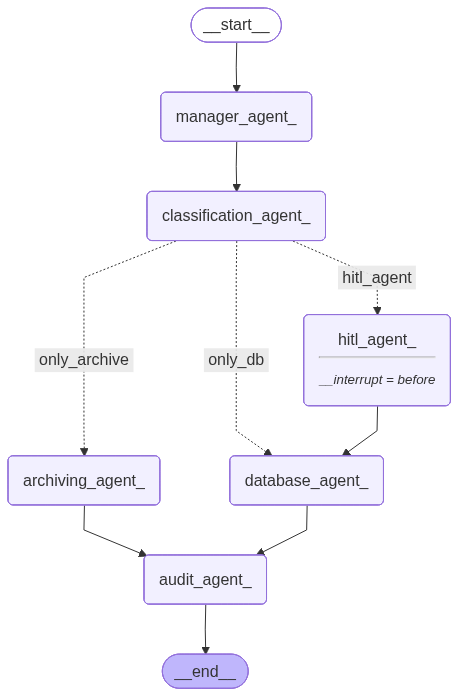

In [11]:
from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

## `run_pipeline()` — Single File

Runs the full pipeline for a single PDF.
- Returns `status: complete` for CEASE / IRRELEVANT
- Returns `status: paused` for UNCERTAIN — waiting for HITL input

In [12]:
def run_pipeline(pdf_file_path: str, document_id: str = None) -> dict:
    """
    Run the full pipeline for a single PDF.
    Returns status='paused' for UNCERTAIN — call resume_hitl() to continue.
    """
    doc_id = document_id or f"DOC-{datetime.now().strftime('%Y%m%d%H%M%S')}"

    initial_state: ClassificationState = {
        "pdf_file_path": pdf_file_path,
        "document_id":   doc_id
    }

    config = {"configurable": {"thread_id": doc_id}}
    result = graph.invoke(initial_state, config=config)

    if result.get("classification") == "UNCERTAIN" and not result.get("hitl_decision"):
        print(f"\n⏸  Paused for HITL review. thread_id={doc_id}")
        return {"status": "paused", "thread_id": doc_id, "state": result}

    print(f"\n✅ Complete — {result.get('classification')}")
    return {"status": "complete", "thread_id": doc_id, "state": result}


print("✅ run_pipeline() defined")

✅ run_pipeline() defined


##  `process_folder()` — Batch Processing 

Loops all PDFs in a folder and:
1. Allocates a unique Document ID (resumes from last audit log index)
2. Runs the pipeline per file
3. Prompts for human input on UNCERTAIN documents
4. Resumes the graph after HITL decision
5. Moves processed files to a `Completed/` subfolder

In [13]:
def process_folder(folder_path: str):
    """
    Batch processes all PDFs in a folder.
    - Resumes document numbering from last audit log entry
    - Handles HITL pause/resume interactively
    - Moves each file to Completed/ after processing
    """
    pdf_files = sorted([
        f for f in os.listdir(folder_path)
        if f.lower().endswith(".pdf")
    ])

    if not pdf_files:
        print(f"No PDF files found in: {folder_path}")
        return

    print(f"Found {len(pdf_files)} PDF(s) to process.\n")

    start_index = get_next_doc_index(os.getenv("AUDIT_LOG_PATH"))
    print(f"Starting from document index: {start_index}\n")

    for index, filename in enumerate(pdf_files, start=start_index):
        pdf_path    = os.path.join(folder_path, filename)
        document_id = f"DOC-{datetime.now().strftime('%Y%m%d%H%M%S')}-{index:03d}"

        print(f"\n{'='*60}")
        print(f"[{index}/{start_index + len(pdf_files) - 1}] File        : {filename}")
        print(f"                       Document ID : {document_id}")
        print(f"{'='*60}")

        # ── Step 1: Run the pipeline ──────────────────────────────
        result = run_pipeline(pdf_path, document_id=document_id)

        # ── Step 2: Handle HITL pause ─────────────────────────────
        if result["status"] == "paused":
            classification_result = result["state"].get("agent_classification_result")

            print(f"\n⚠️  HITL Review Required for : {filename}")
            print(f"   Classification            : {classification_result.classification}")
            print(f"   Confidence Score          : {classification_result.confidence_score}")
            print(f"   Reasoning                 : {classification_result.reasoning}")
            print(f"   Key Phrases               : {classification_result.key_phrases}")
            print(f"\n   Options: CEASE | IRRELEVANT | KEEP_UNCERTAIN")

            # Validate human input
            while True:
                human_decision = input("\n   Your decision: ").strip().upper()
                if human_decision in {"CEASE", "IRRELEVANT", "KEEP_UNCERTAIN"}:
                    break
                print("   ❌ Invalid. Enter CEASE, IRRELEVANT, or KEEP_UNCERTAIN.")

            # ── Step 3: Resume graph after HITL decision ──────────
            config  = {"configurable": {"thread_id": result["thread_id"]}}
            resumed = graph.invoke(Command(resume=human_decision), config=config)
            print(f"\n✅ Resumed — Final: {resumed.get('classification')}")

        else:
            print(f"\n✅ Auto-classified — {result['state']['classification']}")

        # ── Step 4: Move file to Completed/ ───────────────────────
        completed_folder = os.path.join(os.path.dirname(pdf_path), "Completed")
        os.makedirs(completed_folder, exist_ok=True)
        shutil.move(pdf_path, os.path.join(completed_folder, filename))
        print(f"📁 Moved: {filename} → Completed/")

    print(f"\n{'='*60}")
    print(f"✅ All {len(pdf_files)} file(s) processed.")
    print(f"{'='*60}")


print("✅ process_folder() defined")

✅ process_folder() defined


## Run Batch Processing

Point `process_folder()` at your PDF folder and run.

> When a document is **UNCERTAIN**, execution pauses and the cell waits for your input in the prompt below the cell output.

In [14]:
process_folder("Sample Docs")

Found 3 PDF(s) to process.

Starting from document index: 1


[1/3] File        : LoA1.pdf
                       Document ID : DOC-20260322215341-001
[Manager] Processing document: DOC-20260322215341-001
[pdf_to_markdown] Detected mode: native text
[pdf_to_markdown] Processing: Sample Docs\LoA1.pdf
[pdf_to_markdown] Extracted 1 page(s)
[Classification Agent] Classifying document: DOC-20260322215341-001
[Database] Writing to SQLite...
[Database] Saved: DOC-20260322215341-001
[Audit] Writing audit trail...
[Audit] Logged: DOC-20260322215341-001

✅ Complete — CEASE

✅ Auto-classified — CEASE
📁 Moved: LoA1.pdf → Completed/

[2/3] File        : bw_doc_1.pdf
                       Document ID : DOC-20260322215342-002
[Manager] Processing document: DOC-20260322215342-002
[pdf_to_markdown] Detected mode: OCR (scanned)
[pdf_to_markdown] Processing: Sample Docs\bw_doc_1.pdf
[pdf_to_markdown] Extracted 1 page(s)
[Classification Agent] Classifying document: DOC-20260322215342-002
[Archiving] Writ

Deserializing unregistered type __main__.ClassificationResult from checkpoint. This will be blocked in a future version. Add to allowed_msgpack_modules to silence: [('__main__', 'ClassificationResult')]



[HITL] ⚠️  Document requires human review.
  Reasoning : The document requests a stop to specific outreach modes pending confirmation of authority to contact, but does not explicitly demand a universal cessation of all contact. The language is intentionally circumspect and does not clearly imply a cease and desist request. The tone is formal and legal, suggesting a potential cease and desist request, but the intent is not explicit.
  Score     : 60
  Phrases   : ['stop to specific outreach modes', 'refrain from initiating further direct contact', "without prejudice to the Interested Party's rights"]
  Override options: CEASE | IRRELEVANT | KEEP_UNCERTAIN
[HITL] Decision recorded: CEASE
[Database] Writing to SQLite...
[Database] Saved: DOC-20260322215343-003
[Audit] Writing audit trail...
[Audit] Logged: DOC-20260322215343-003

✅ Resumed — Final: CEASE
📁 Moved: notice_1.pdf → Completed/

✅ All 3 file(s) processed.


## View Audit Log (Last 20 Lines)

In [15]:
audit_log_path = os.getenv("AUDIT_LOG_PATH")

if os.path.exists(audit_log_path):
    with open(audit_log_path, "r", encoding="utf-8") as f:
        lines = f.readlines()
    print(f"Total lines in audit log: {len(lines)}\n")
    print("".join(lines))
else:
    print("Audit log not found. Run process_folder() first.")

Total lines in audit log: 49


Document ID : DOC-20260322215341-001
File path : Sample Docs\LoA1.pdf
Final result: CEASE (score=95)
Audit trail:
  [2026-03-22 21:53:41] [MANAGER] Received document_id=DOC-20260322215341-001. Starting pipeline.
  [2026-03-22 21:53:41] [MANAGER] Markdown Metadata: PDF File Type=native text, extracted_pages=1
  [2026-03-22 21:53:41] [MANAGER] Completed PDF to Markdown conversion.
  [2026-03-22 21:53:41] [CLASSIFICATION_AGENT] Starting classification for document_id=DOC-20260322215341-001
  [2026-03-22 21:53:42] [CLASSIFICATION_AGENT] 
Classification Category : CEASE
Confidence Score        : 95
Reasoning               : The document explicitly states 'Cease and desist all communications regarding this account' and 'Do not contact me by any mode of communication', indicating a clear intent to stop all communication. The language used is direct and unambiguous, with a clear request to cease contact. The document also grants power of attorney to a law group, 

## Query SQLite Results

In [16]:
conn = sqlite3.connect(os.getenv("SQL_LITE_DB_PATH"))
conn.row_factory = sqlite3.Row
query = """
    SELECT document_id, classification, created_at
    FROM classifications
    ORDER BY created_at DESC
    LIMIT 20
"""
rows = conn.execute(query).fetchall()

conn.close()

print(f"{'Document ID':<30} {'Classification':<15} {'Score':<8} {'Created At'}")
print("-" * 75)
for row in rows:
    print(f"{row['document_id']:<30} {row['classification']:<15} {row['created_at']}")

Document ID                    Classification  Score    Created At
---------------------------------------------------------------------------
DOC-20260322215343-003         CEASE           2026-03-22 21:53:52
DOC-20260322215341-001         CEASE           2026-03-22 21:53:42


## Archive Results

In [17]:
archive_path = os.getenv("ARCHIVE_PATH")

if not os.path.exists(archive_path):
    print(f"Archive file not found: {archive_path}")
else:
    print(f"Archive file: {archive_path}\n")
    with open(archive_path, "r", encoding="utf-8") as f:
        for idx, line in enumerate(f, start=1):
            print(f"{idx:04d}: {line.strip()}")

Archive file: archives\\classification_agent_archive.jsonl

0001: {"document_id": "DOC-20260322215342-002", "classification": "IRRELEVANT", "confidence_score": 100, "reasoning": "The document does not contain any phrases or language that indicate a desire to stop communication. It appears to be a formal notice regarding a limited Power of Attorney representation, which is unrelated to a cease and desist request.", "key_phrases": ["Notice Regarding Limited Power of Attorney Representation", "to notify your office of a valid instrument granting authority", "Please record the existence of the limited Power of Attorney document"], "pdf_file_path": "Sample Docs\\bw_doc_1.pdf", "hitl_decision": "", "archived_at": "2026-03-22 21:53:43"}
